# Decomposing the trend signal

The 4-week trailing return on a coin is two things added together. The market's own 4-week return, shared by every coin, and the residual, how much the coin beat or lagged the market. The trend book bets the sign of the sum.

Split it. Bet each piece on its own and read what it earns. Ask whether the cross-section, the residual, trends or reverses, and at what horizon. Then fit next-week return on the pieces plus funding, to see how much is market timing, how much is coin selection, and how much is carry.

## Setup

Rebuild the book helpers and the panel, then the market return and the 4-week own, market and residual returns.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import panel

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

p = panel.load()
W, R, LIQ, VOL, F = p.weekly, p.simple.fillna(0.0), p.liquidity, p.vol, p.funding
COST = pd.DataFrame(np.where(LIQ >= 1e7, 7.5e-4, 15e-4), index=LIQ.index, columns=LIQ.columns)

def run(w, cost_mult=1.0):
    w = w.fillna(0.0)
    turn = (w - w.shift(1).fillna(0.0)).abs()
    net = (w * R).sum(axis=1) - (w * F).sum(axis=1) - (turn * COST * cost_mult).sum(axis=1)
    return net.loc[(w.abs().sum(axis=1) > 0).idxmax():]

def sharpe(x):
    return x.mean() / x.std() * np.sqrt(52) if len(x) > 2 and x.std() > 0 else np.nan

def sized(sig, floor=1e7):
    elig = (LIQ >= floor) & VOL.notna() & (VOL > 0) & sig.notna()
    raw = (sig / VOL).where(elig)
    return raw.div(raw.abs().sum(axis=1), axis=0)

def book(sig):
    net = run(sized(sig.shift(1)))
    tr = pd.Series(False, index=net.index)
    tr.iloc[np.concatenate(np.array_split(np.arange(len(net)), 5)[:3])] = True
    return sharpe(net), sharpe(net[tr]), sharpe(net[~tr])

liquid = LIQ >= 1e7
market_ret = W.where(liquid).mean(axis=1)
own4 = W.rolling(4, min_periods=4).sum()
mkt4 = market_ret.rolling(4, min_periods=4).sum()
resid4 = own4.sub(mkt4, axis=0)
print(f'panel {W.shape}  {W.index.min().date()} .. {W.index.max().date()}')

panel (349, 681)  2020-01-05 .. 2026-09-06


## The pieces

Four books at 4 weeks, same sizing. The plain trend, sign of the own return. The market trend, sign of the market return applied to every coin. The residual momentum, long the coins that beat the market and short those that lagged. And its reverse.

In [2]:
books = {'own trend, sign(own4)': np.sign(own4),
         'market trend, sign(mkt4)': (own4 * 0).add(np.sign(mkt4), axis=0),
         'residual momentum, sign(resid4)': np.sign(resid4),
         'residual reversal, -sign(resid4)': -np.sign(resid4)}
dec = pd.DataFrame({n: book(s) for n, s in books.items()}, index=['all', 'train', 'unseen']).T
print('net Sharpe'); print(dec.round(2))

net Sharpe
                                   all  train  unseen
own trend, sign(own4)             0.85   1.04    0.55
market trend, sign(mkt4)          0.80   0.87    0.67
residual momentum, sign(resid4)   0.28   0.23    0.38
residual reversal, -sign(resid4) -0.49  -0.41   -0.69


The trend book is the market book with a small kicker. Timing the market alone makes 0.80, the full per coin book 0.85, so coin selection adds 0.05. And the selection that adds it is momentum, not reversal. Long the coins that beat the market makes 0.28, and its reverse loses 0.49. At 4 weeks the cross-section trends.

## Where the cross-section reverses

The residual book again, sign of the coin's return over the market, at formation horizons from 1 to 12 weeks.

In [3]:
hz = {}
for L in [1, 2, 3, 4, 6, 8, 12]:
    ownL = W.rolling(L, min_periods=L).sum()
    resid = ownL.sub(market_ret.rolling(L, min_periods=L).sum(), axis=0)
    hz[L] = dict(zip(['all', 'train', 'unseen'], book(np.sign(resid))))
hz = pd.DataFrame(hz).T; hz.index.name = 'L'
print('residual book net Sharpe by formation horizon'); print(hz.round(2))

residual book net Sharpe by formation horizon
     all  train  unseen
L                      
1  -0.48  -0.68   -0.07
2  -0.41  -0.49   -0.24
3  -0.22  -0.38    0.17
4   0.28   0.23    0.38
6   0.19  -0.12    0.76
8   0.14   0.01    0.35
12  0.07   0.05    0.09


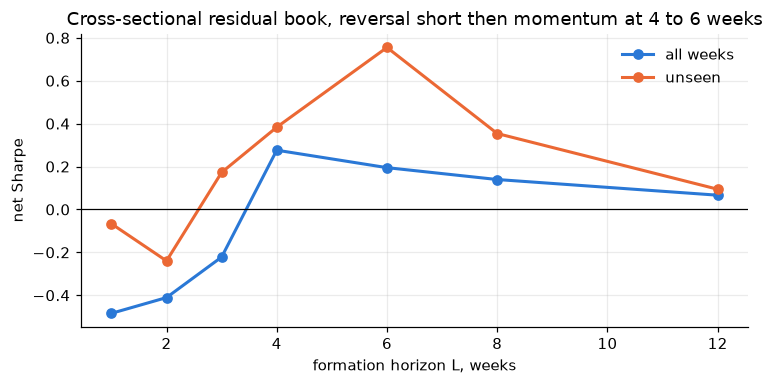

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(hz.index, hz['all'], marker='o', color=BLUE, label='all weeks')
ax.plot(hz.index, hz['unseen'], marker='o', color=ORANGE, label='unseen')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('formation horizon L, weeks'); ax.set_ylabel('net Sharpe')
ax.set_title('Cross-sectional residual book, reversal short then momentum at 4 to 6 weeks')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

The cross-section reverses at short horizons and trends at longer ones. Over 1 and 2 weeks, betting on the coins that just outperformed loses, 0.48 and 0.41. It crosses zero around 3 weeks and turns positive at 4 to 6, best at 6 with 0.76 unseen. By 12 it fades.

So the 1 to 2 week reversal is a real and separate signal at a short horizon. It is not inside the 4-week trend, where the cross-section already trends. Reversal belongs to the mean-reversion lane at its own horizon, not to this one.

## Fitting the pieces to next-week return

Regress next-week return on the standardised market, residual and funding terms, pooled across coins and weeks. Coefficients in basis points per standard deviation, and their t-stats.

In [5]:
fund4 = F.rolling(4, min_periods=4).sum()
fwd = R.shift(-1)
elig = liquid & VOL.notna() & own4.notna() & resid4.notna() & fund4.notna() & fwd.notna()
def zc(df):
    v = df.where(elig)
    return v.sub(v.mean(axis=1), axis=0).div(v.std(axis=1), axis=0)
terms = {'market 4wk': zc((own4 * 0).add(mkt4, axis=0)), 'residual 4wk': zc(resid4), 'funding 4wk': zc(fund4)}
y = fwd.where(elig).values.ravel()
X = np.column_stack([np.ones(y.size)] + [t.values.ravel() for t in terms.values()])
ok = ~np.isnan(X).any(1) & ~np.isnan(y)
A, b = X[ok], y[ok]
coef, *_ = np.linalg.lstsq(A, b, rcond=None)
res = b - A @ coef
se = np.sqrt(np.sum(res ** 2) / (ok.sum() - A.shape[1]) * np.diag(np.linalg.inv(A.T @ A)))
ols = pd.DataFrame({'coef bps': coef * 1e4, 't': coef / se}, index=['const'] + list(terms)).round(2)
print(f'pooled OLS of next-week return on standardised terms, n={ok.sum()}'); print(ols)


pooled OLS of next-week return on standardised terms, n=13521
              coef bps      t
const             2.34   0.15
market 4wk      203.98  12.74
residual 4wk     52.90   3.29
funding 4wk      57.83   3.60


All three predict positively and the market dominates. A one standard deviation stronger market trend adds 204 bps to next week at t 12.7. The residual adds 53 at t 3.3, the weak cross-sectional momentum again. Funding adds 58 at t 3.6, separate from both price terms.

That funding term settles the carry question. The trend result is not just carry, the price terms hold with funding in the regression, and funding carries its own small independent signal on top.

## Verdict

The 4-week trend is a strong market-timing beta with two weak kickers. Timing the market is almost all of it, 0.80 of the 0.85. Coin selection adds a little, and at this horizon it is cross-sectional momentum, not reversal. Funding adds a little more, independent of price, so the signal is not carry in disguise.

The cross-section reverses only at 1 to 2 weeks, a separate short-horizon signal that belongs to the mean-reversion lane, not to the 4-week trend. This subsumes the funding-aware sign, funding is a small separate positive term rather than the whole story.